<a href="https://colab.research.google.com/github/fox-buddy/MachineLearning-Collection/blob/main/spaceship_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd

Importand for preprocessing with scikit and Training Model with Keras
- Fit preprocessing on train data only (fit_transform or fit and transform separately).
- Transform val/test with the same fitted transformer (transform)
- Convert transformed output to a NumPy array (and often float32) before passing to Keras.
- If your transformer outputs sparse matrices (e.g., OneHotEncoder), convert with .toarray() if needed.

Both Preprocessor and Model needs to be saved to use this combination afterwards

In [7]:
X_train = pd.read_csv('/content/SpaceshipTitanic/X_train_splitted.csv')
X_test = pd.read_csv('/content/SpaceshipTitanic/X_test_splitted.csv')


X_train_raw = pd.read_csv('/content/SpaceshipTitanic/train.csv')
X_test_raw = pd.read_csv('/content/SpaceshipTitanic/test.csv')

In [8]:
X_train_raw.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
y_train = X_train_raw["Transported"]

In [10]:
y_train

,Transported
0,False
1,True
2,False
3,False
4,True
...,...
8688,False
8689,False
8690,True
8691,False


In [11]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,groupid,deck,deckroom,deckside
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,1,B,0,P
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,2,F,0,S
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,3,A,0,S
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,3,A,0,S
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,4,F,1,S


In [12]:
X_train_raw.Transported.value_counts()

,count
Transported,
True,4378
False,4315


In [13]:
X_train = X_train.drop(columns=["deckroom", "deckside"])
X_test = X_test.drop(columns=["deckroom", "deckside"])

In [14]:
# imports for plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

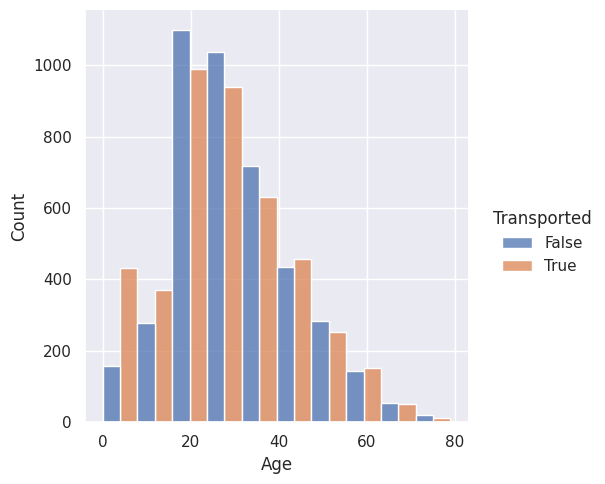

In [15]:
# showing distribution of numerical values. Number of bins will automatically be determined based on data structure
sns.displot(X_train_raw, x="Age", bins=10, hue="Transported", multiple="dodge")

# transported is basically toggled at age 20

In [16]:
X_train.Age.value_counts()

,count
Age,
24.0,324
18.0,320
21.0,311
19.0,293
23.0,292
...,...
75.0,4
79.0,3
78.0,3


In [17]:
# Binning Age
age_bins = [0, 4, 12, 18, 25, 40, 50, 60, 80]
age_labels = ['Baby', 'Child', 'Teenager', 'Young Adult', 'Adult', 'Prime Aduld', 'Senior', 'Elder']

In [18]:
X_train_raw["AgeGroup"] = pd.cut(X_train_raw.Age, bins=age_bins, labels=age_labels, include_lowest=True)

In [19]:
X_train["AgeGroup"] = pd.cut(X_train_raw.Age, bins=age_bins, labels=age_labels, include_lowest=True)
X_test["AgeGroup"] = pd.cut(X_test.Age, bins=age_bins, labels=age_labels, include_lowest=True)

In [20]:
X_train = X_train.drop(columns=["Age"])
X_test = X_test.drop(columns=["Age"])

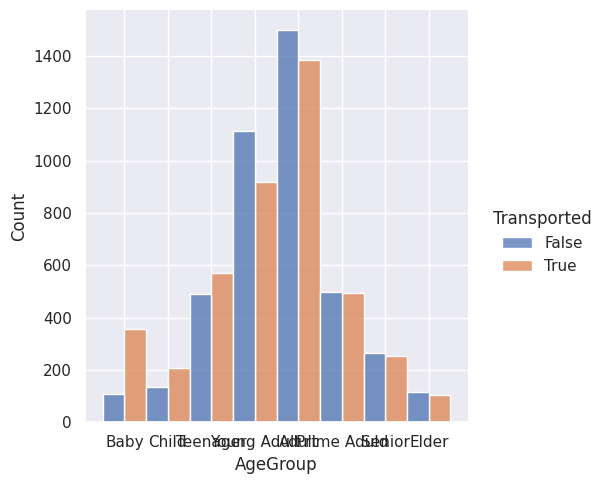

In [21]:
sns.displot(X_train_raw, x="AgeGroup", bins=10, hue="Transported", multiple="dodge")


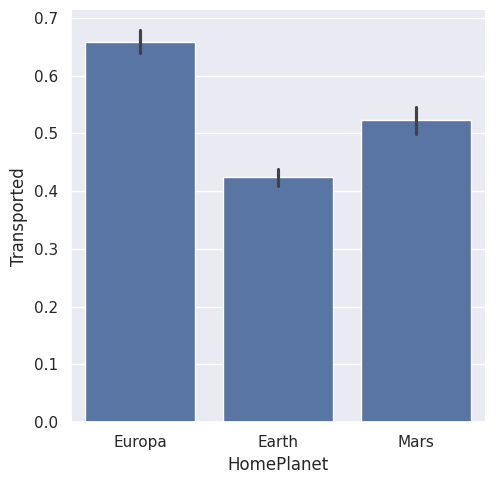

In [22]:
sns.catplot(data=X_train_raw, x="HomePlanet", y="Transported", kind="bar")

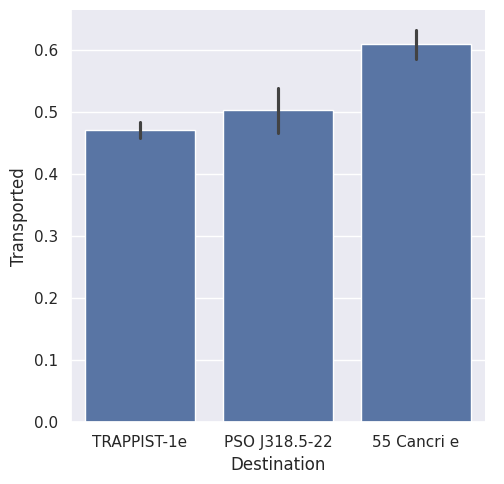

In [23]:
sns.catplot(data=X_train_raw, x="Destination", y="Transported", kind="bar")

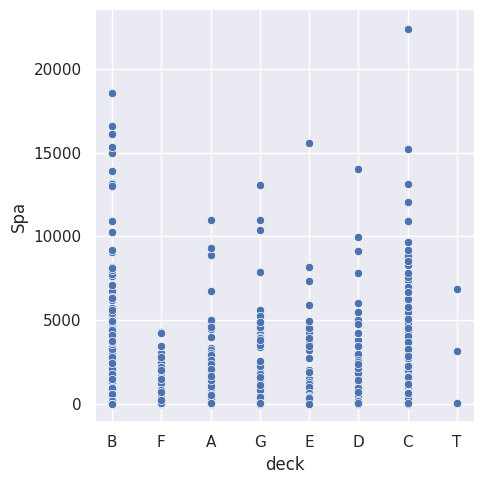

In [24]:
sns.relplot(X_train, x="deck", y="Spa")

In [25]:
X_train_raw.corr(numeric_only=True)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.207075
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,1.000000


In [26]:
X_train = X_train.drop(columns=["FoodCourt", "ShoppingMall"])
X_test = X_test.drop(columns=["FoodCourt", "ShoppingMall"])

In [27]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Destination,VIP,RoomService,Spa,VRDeck,groupid,deck,AgeGroup
0,0001_01,Europa,False,TRAPPIST-1e,False,0.0,0.0,0.0,1,B,Adult
1,0002_01,Earth,False,TRAPPIST-1e,False,109.0,549.0,44.0,2,F,Young Adult
2,0003_01,Europa,False,TRAPPIST-1e,True,43.0,6715.0,49.0,3,A,Senior
3,0003_02,Europa,False,TRAPPIST-1e,False,0.0,3329.0,193.0,3,A,Adult
4,0004_01,Earth,False,TRAPPIST-1e,False,303.0,565.0,2.0,4,F,Teenager


In [28]:
# Data looks good here
# now scaling, imputing and encoding

X_test.set_index("PassengerId")

,HomePlanet,CryoSleep,Destination,VIP,RoomService,Spa,VRDeck,groupid,deck,AgeGroup
PassengerId,,,,,,,,,,
0013_01,Earth,True,TRAPPIST-1e,False,0.0,0.0,0.0,13,G,Adult
0018_01,Earth,False,TRAPPIST-1e,False,0.0,2823.0,0.0,18,F,Young Adult
0019_01,Europa,True,55 Cancri e,False,0.0,0.0,0.0,19,C,Adult
0021_01,Europa,False,TRAPPIST-1e,False,0.0,181.0,585.0,21,C,Adult
0023_01,Earth,False,TRAPPIST-1e,False,10.0,0.0,0.0,23,F,Young Adult
...,...,...,...,...,...,...,...,...,...,...
9266_02,Earth,True,TRAPPIST-1e,False,0.0,0.0,0.0,9266,G,Adult
9269_01,Earth,False,TRAPPIST-1e,False,0.0,10.0,144.0,9269,G,Prime Aduld
9271_01,Mars,True,55 Cancri e,False,0.0,0.0,0.0,9271,D,NaN


In [29]:
X_train.set_index("PassengerId")

,HomePlanet,CryoSleep,Destination,VIP,RoomService,Spa,VRDeck,groupid,deck,AgeGroup
PassengerId,,,,,,,,,,
0001_01,Europa,False,TRAPPIST-1e,False,0.0,0.0,0.0,1,B,Adult
0002_01,Earth,False,TRAPPIST-1e,False,109.0,549.0,44.0,2,F,Young Adult
0003_01,Europa,False,TRAPPIST-1e,True,43.0,6715.0,49.0,3,A,Senior
0003_02,Europa,False,TRAPPIST-1e,False,0.0,3329.0,193.0,3,A,Adult
0004_01,Earth,False,TRAPPIST-1e,False,303.0,565.0,2.0,4,F,Teenager
...,...,...,...,...,...,...,...,...,...,...
9276_01,Europa,False,55 Cancri e,True,0.0,1643.0,74.0,9276,A,Prime Aduld
9278_01,Earth,True,PSO J318.5-22,False,0.0,0.0,0.0,9278,G,Teenager
9279_01,Earth,False,TRAPPIST-1e,False,0.0,1.0,0.0,9279,G,Adult


In [30]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  8693 non-null   object  
 1   HomePlanet   8492 non-null   object  
 2   CryoSleep    8476 non-null   object  
 3   Destination  8511 non-null   object  
 4   VIP          8490 non-null   object  
 5   RoomService  8512 non-null   float64 
 6   Spa          8510 non-null   float64 
 7   VRDeck       8505 non-null   float64 
 8   groupid      8693 non-null   int64   
 9   deck         8693 non-null   object  
 10  AgeGroup     8514 non-null   category
dtypes: category(1), float64(3), int64(1), object(6)
memory usage: 688.1+ KB


In [31]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn. preprocessing import StandardScaler

num_columns = ["RoomService", "Spa", "VRDeck"]
cat_cols_unknown_encode = ["HomePlanet", "Destination"]
cat_cols_mf_encode = ["AgeGroup", "VIP", "CryoSleep"]
#cat_cols_only_encode = ["groupid", "deck"]
cat_cols_only_encode = ["deck"]

In [32]:
num_pipeline = Pipeline([
    ("num_imputer", SimpleImputer(strategy="mean"))
    , ("num_scaler", StandardScaler())
])

cat_pipeline_unknown = Pipeline([
    ("cat_unk_imputer", SimpleImputer(strategy="constant", fill_value='unknown'))
    , ("cat_unk_encoder", OneHotEncoder(handle_unknown="ignore"))
])

# cat_pipeline_unknown = Pipeline([
#     ("cat_unk_imputer", SimpleImputer(strategy="most_frequent"))
#     , ("cat_unk_encoder", OneHotEncoder(handle_unknown="ignore"))
# ])

cat_pipeline_mostfrequent = Pipeline([
    ("cat_mf_imputer", SimpleImputer(strategy="most_frequent"))
    , ("cat_unk_encoder", OneHotEncoder(handle_unknown="ignore"))
])

cat_pipeline_only = Pipeline([
    ("cat_only_encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [33]:
from sklearn.compose import ColumnTransformer

data_col_transformer = ColumnTransformer([
    ("num_transformer", num_pipeline, num_columns)
    , ("cat_unkimpute_transformer", cat_pipeline_unknown, cat_cols_unknown_encode)
    , ("cat_mfimpute_transformer", cat_pipeline_mostfrequent, cat_cols_mf_encode)
    , ("cat_onlyencode_transformer", cat_pipeline_only, cat_cols_only_encode)
])

In [34]:
X_train = X_train.drop(columns=["groupid"])
X_test = X_test.drop(columns=["groupid"])

In [35]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  8693 non-null   object  
 1   HomePlanet   8492 non-null   object  
 2   CryoSleep    8476 non-null   object  
 3   Destination  8511 non-null   object  
 4   VIP          8490 non-null   object  
 5   RoomService  8512 non-null   float64 
 6   Spa          8510 non-null   float64 
 7   VRDeck       8505 non-null   float64 
 8   deck         8693 non-null   object  
 9   AgeGroup     8514 non-null   category
dtypes: category(1), float64(3), object(6)
memory usage: 620.2+ KB


In [36]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  4277 non-null   object  
 1   HomePlanet   4190 non-null   object  
 2   CryoSleep    4184 non-null   object  
 3   Destination  4185 non-null   object  
 4   VIP          4184 non-null   object  
 5   RoomService  4195 non-null   float64 
 6   Spa          4176 non-null   float64 
 7   VRDeck       4197 non-null   float64 
 8   deck         4277 non-null   object  
 9   AgeGroup     4186 non-null   category
dtypes: category(1), float64(3), object(6)
memory usage: 305.4+ KB


In [37]:
X_train_prepared = data_col_transformer.fit_transform(X_train)

In [38]:
X_test_prepared = data_col_transformer.transform(X_test)

In [39]:
from sklearn.model_selection import cross_val_score

In [40]:
from sklearn.ensemble import RandomForestClassifier
rand_tree_clf = RandomForestClassifier(n_estimators=200)

In [41]:
#rand_tree_score = cross_val_score(estimator=rand_tree_clf, X= X_train_prepared, y=y_train, cv=5)

In [42]:
#rand_tree_score.mean()

In [43]:
X_train_prepared.shape

(8693, 31)

In [44]:
X_train_prepared.shape[1:]

(31,)

In [45]:
X_test_prepared.shape

(4277, 31)

In [46]:
import tensorflow as tf

In [47]:
tf.random.set_seed(42)

In [48]:
#model.reset_metrics

NameError: name 'model' is not defined

In [59]:
tf.keras.backend.clear_session()
# clear because Keras saves the current session and add changes the model

In [60]:
# Hyperparameters:
# n_hidden: 6
# n_neurons: 41
# learning_rate: 0.00017030485110152736
# optimizer: adam
# Score: 0.8045976758003235


model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape=[31,]))
model.add(tf.keras.layers.Dense(41, activation="relu"))
model.add(tf.keras.layers.Dense(41, activation="relu"))
model.add(tf.keras.layers.Dense(41, activation="relu"))
model.add(tf.keras.layers.Dense(41, activation="relu"))
model.add(tf.keras.layers.Dense(41, activation="relu"))
model.add(tf.keras.layers.Dense(41, activation="relu"))


# 0.8057471513748169 with SGD(learning_rate=3e-4, momentum=0.9, nesterov=True)
# model.add(tf.keras.layers.Dense(31, activation="relu"))
# model.add(tf.keras.layers.Dense(31, activation="relu"))
# model.add(tf.keras.layers.Dense(31, activation="relu"))

model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

In [61]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 41)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,964 (38.92 KB)

 Trainable params: 9,964 (38.92 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# model.compile(loss="binary_crossentropy", optimizer="sgd", metrics=["accuracy"])
# Sie Buch Seite 357 zur Auswahl der Verlustfunktion

# Best in many cases -
# from tensorflow.keras.optimizers import Adam
# model.compile(loss="binary_crossentropy", optimizer=Adam(learning_rate=0.00017030485110152736), metrics=["accuracy"])

# When overfitting try AdamW
#from tensorflow.keras.optimizers import AdamW
#model.compile(loss="binary_crossentropy", optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-4), metrics=["accuracy"])

# SGD Can work well with hyperparameter Tuning
# 1. Learning rate (1e-2, 1e-3, 3e-4, 1e-4)
# 2. Batch size (16, 32, 64, 128)
# 3. Epochs / early stopping patience
# 4. Regularization (dropout, L2, weight decay)
# 5. Model size (layers/units)
from tensorflow.keras.optimizers import SGD
model.compile(loss="binary_crossentropy", optimizer=SGD(learning_rate=3e-4, momentum=0.9, nesterov=True), metrics=["accuracy"])


In [ ]:
# Validation Data
# 90% ca bei 7823 Datensätzen
# Also Train bis zu den letzten 870 und valid ab
# X_train_prepared_train, y_train_tain = X_train_prepared[:-870], y_train[:-870]
# X_train_prepared_valid, y_train_valid = X_train_prepared[-870:], y_train[-870:]

In [63]:
from tensorflow.keras.callbacks import EarlyStopping



In [64]:
early_topping_criteria = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

In [65]:
history = model.fit(X_train_prepared, y_train, epochs=60, batch_size=16, validation_split=0.1, callbacks=[early_topping_criteria])

Epoch 1/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5096 - loss: 0.6946 - val_accuracy: 0.4736 - val_loss: 0.6919
Epoch 2/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5181 - loss: 0.6858 - val_accuracy: 0.5667 - val_loss: 0.6790
Epoch 3/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6053 - loss: 0.6711 - val_accuracy: 0.6655 - val_loss: 0.6566
Epoch 4/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7122 - loss: 0.6424 - val_accuracy: 0.7195 - val_loss: 0.6093
Epoch 5/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7460 - loss: 0.5868 - val_accuracy: 0.7483 - val_loss: 0.5501
Epoch 6/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7616 - loss: 0.5293 - val_accuracy: 0.7575 - val_loss: 0.5093
Epoch 7/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7669 - loss: 0.4938 - val_accuracy: 0.7563 - val_loss: 0.4832
Epoch 8/60
489/489 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7725 - loss: 0.4723 - val_accuracy: 0.

In [66]:
# Evaluate
print("Best val_accuracy:", max(history.history["val_accuracy"]))

Best val_accuracy: 0.8091953992843628


In [67]:
# predict
#y_pred = model.predict(X_test_prepared)

y_prob = model.predict(X_test_prepared)   # e.g. 0.0..1.0
# y_pred = (y_prob >= 0.5).astype(int)

134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step


In [68]:
y_prob

array([[0.5601505 ],
       [0.0384252 ],
       [0.99495816],
       ...,
       [0.9729292 ],
       [0.9016428 ],
       [0.53950906]], dtype=float32)

In [69]:
y_prob = y_prob.ravel()   # Flatted 1D array for Data Frame

In [70]:
y_prob

array([0.5601505 , 0.0384252 , 0.99495816, ..., 0.9729292 , 0.9016428 ,
       0.53950906], dtype=float32)

In [71]:
y_pred = (y_prob >= 0.5)

In [72]:
y_pred

array([ True, False,  True, ...,  True,  True,  True])

In [91]:
y_pred.shape

(4277,)

In [92]:
y_pred

array([ True, False,  True, ...,  True,  True,  True])

In [98]:
data = {
    "PassengerId": X_test["PassengerId"].tolist()
    , "Transported": y_pred.tolist()
    }

In [99]:
result_frame = pd.DataFrame(data)

In [100]:
result_frame.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [102]:
result_frame.to_csv('./submission.csv', index=False)

In [ ]:
# Tuning With Keras Tuner
#%pip install  keras-tuner

In [ ]:
#defining Tuning function

# import keras_tuner as kt

# def build_model(hp):
#   # First Part Definition of hyper Parameters
#   # Hidden neurons
#   n_hidden = hp.Int("n_hidden", min_value=0, max_value=10, default=3)

#   # Neuron Count
#   n_neurons = hp.Int("n_neurons", min_value=16, max_value=128)

#   # Learning Rate
#   learning_rate = hp.Float("learning_rate", min_value=1e-5, max_value=1e-1, sampling="log")

#   # We could also define some special parameters per Optimizer. For Example momentum for sgd

#   # optimizer
#   optimizer = hp.Choice("optimizer", values=["sgd", "adam", "adamw"])

#   if optimizer == "sgd":
#     optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
#   elif optimizer == "adam":
#     optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
#   else:
#     optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate)


#   # Seconde Part - Build Model
#   model = tf.keras.Sequential()

#   # model.add(tf.keras.layers.Flatten())  # Only multi dimensional Data

#   # Add hidden layers
#   for _ in range(n_hidden):
#     model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))

#   # Add output layer
#   model.add(tf.keras.layers.Dense(1, activation="sigmoid"))


#   model.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])

#   return model



In [ ]:
# Grid Search is also Possible with GridSearch
# objective possibilities in this case are the same like listed in the training epochs: accuracy, loss, val_accuracy, val_loss

#random_search_tuner = kt.RandomSearch(
#    build_model, objective="val_accuracy", max_trials=20, overwrite=True, directory="SpaceShipTunerGridSearch", project_name="SpaceShipTitanicNeural", seed=42
#)

In [ ]:
#random_search_tuner.search(X_train_prepared, y_train, epochs=60, validation_split=0.1, callbacks=[early_topping_criteria])

In [ ]:
#top3_models  = random_search_tuner.get_best_models(num_models=3)
#top3_params = random_search_tuner.get_best_hyperparameters(num_trials=3)

#best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]

In [ ]:
#best_trial.summary()
# Trial 04 summary
# Hyperparameters:
# n_hidden: 6
# n_neurons: 41
# learning_rate: 0.00017030485110152736
# optimizer: adam
# Score: 0.8045976758003235
